# I'm gonna run a test model here before diving deep into the ultimate model

## I. Introduction
This document only focus on a simple ML model using lightgbm to test the dataset.
I will note my progress making and trying simple model (only use libraries and modules) step-by-step.


## II, Tutorial
### Step 1: Import library.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import json
from datetime import datetime

### Step 2:Prepare the dataset

In [2]:
file_path = r'G:\url-analysis\src\data\processed_url_update.csv'
url_data = pd.read_csv(file_path, encoding_errors='ignore')
url_data.info()

print(url_data.isnull().sum())
print("\nPhân phối nhãn:")
print(url_data['type'].value_counts())

C:\Users\AD\AppData\Local\Temp\ipykernel_55956\1589477046.py:2: DtypeWarning: Columns (0: scheme, 1: query, 2: fragment) have mixed types. Specify dtype option on import or set low_memory=False.
  url_data = pd.read_csv(file_path, encoding_errors='ignore')


<class 'pandas.DataFrame'>
RangeIndex: 672186 entries, 0 to 672185
Data columns (total 72 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   url                               672186 non-null  str    
 1   type                              672186 non-null  str    
 2   url length                        672186 non-null  int64  
 3   scheme                            208601 non-null  str    
 4   netloc                            672168 non-null  str    
 5   path                              647002 non-null  str    
 6   query                             140416 non-null  str    
 7   fragment                          459 non-null     str    
 8   subdomain                         258824 non-null  str    
 9   domain                            672180 non-null  str    
 10  number_of_part                    672186 non-null  int64  
 11  has_scheme                        672186 non-null  int64  
 12 

### Step 3: split the dataset, X is the set of features used to test, y is the label

In [3]:
X = pd.DataFrame(url_data).drop(columns = ['url', 'type', 'scheme', 'netloc', 'path', 'query', 'fragment', 'subdomain', 'domain'])
print(X.head())

# y is the tag for supervised learning
y = url_data.type
print(y)

   url length  number_of_part  has_scheme  has_netloc  has_path  has_params  \
0          16               1           0           1         0           0   
1          35               2           0           1         1           0   
2          31               2           0           1         1           0   
3          88               4           1           1         1           0   
4         235               4           1           1         1           0   

   has_query  has_fragment  has_username  has_password  ...  has_uuid_path  \
0          0             0             0             0  ...              0   
1          0             0             0             0  ...              0   
2          0             0             0             0  ...              0   
3          1             0             0             0  ...              0   
4          1             0             0             0  ...              0   

   download_param  free_host  free_host_download  suspic

### Step 4: write loss_function

In [4]:
def loss_function():
    pass
def gradient_descent():
    pass
def hessian():
    pass

### Step 5: split X, y to X_train, X_test, y_train, y_test, X_val, y_val to train and test using LightGBM model

#### First split

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.15, stratify=y, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.177, stratify=y_temp, random_state = 42)
print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

Train: 470227 | Validation: 101131 | Test: 100828


#### DATA LEAKAGE CHECK FOR NORMAL SPLIT (check overlap)

In [6]:
# 1. Check duplicate URL
print("Số URL trùng:", url_data['url'].duplicated().sum())

# 2. Trích domain để check overlap giữa các tập
from src.features.feature_extraction import extract_url, DOMAIN, SUFFIX
url_data['domain'] = url_data['url'].apply(
    lambda u: '.'.join(filter(None, extract_url(u)[DOMAIN:SUFFIX+1]))
)

train_domains = set(url_data.loc[X_train.index, 'domain'])
test_domains  = set(url_data.loc[X_test.index, 'domain'])
val_domains   = set(url_data.loc[X_val.index, 'domain'])

overlap_train_test = train_domains & test_domains
print(f"Domain trùng train/test: {len(overlap_train_test)} "
      f"({len(overlap_train_test)/len(test_domains):.1%} của test)")

Số URL trùng: 10210
Domain trùng train/test: 18812 (49.0% của test)


#### DROP DUPLICATES DATA AND UPDATE X, y

In [7]:
url_data = url_data.drop_duplicates(subset='url').reset_index(drop=True)
X = pd.DataFrame(url_data).drop(columns = ['url', 'type', 'scheme', 'netloc', 'path', 'query', 'fragment', 'subdomain', 'domain'])
y = url_data.type


#### StratifiedGroupKFold split

In [8]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=36)
folds = list(sgkf.split(X, y, groups = url_data['domain']))

test_idx = folds[0][1]
val_idx = folds[1][1]
train_idx = np.concatenate([folds[i][1] for i in range(2,10)])

X_train_sgkf, y_train_sgkf = X.iloc[train_idx], y.iloc[train_idx]
X_test_sgkf, y_test_sgkf = X.iloc[test_idx], y.iloc[test_idx]
X_val_sgkf, y_val_sgkf = X.iloc[val_idx], y.iloc[val_idx]

#### DATA LEAKAGE CHECK FOR STRATIFIED GROUP K FOLD SPLIT (check overlap)

In [9]:
train_domains = set(url_data.loc[train_idx, 'domain'])
test_domains  = set(url_data.loc[test_idx, 'domain'])
print("Domain trùng train/test:", len(train_domains & test_domains))

Domain trùng train/test: 0


#### Train model

In [10]:
le = LabelEncoder()
y_train_sgkf = le.fit_transform(y_train_sgkf)
y_val_sgkf = le.transform(y_val_sgkf)
y_test_sgkf = le.transform(y_test_sgkf)


params = {
    'objective' : 'multiclass',
    'class_weight' : 'balanced',
    'num_class' : 4,
    'boosting_type' : 'gbdt',
    'random_state' : 42,
    'verbose' : -1,
    'n_jobs' : -1,

    #complexity
    'n_estimators' : 4000,
    'learning_rate' : 0.025,
    'max_depth' : 5,
    'num_leaves' : 24,
    'min_data_in_leaf' : 50,

    #subsampling
    'colsample_bytree' : 0.75,
    'subsample' : 0.8,
    'subsample_freq' : 1,

    #early stoping
    'early_stopping_rounds' : 100,

    #regularization
    'reg_alpha' : 0.1, #L1 regularization
    'reg_lambda' : 1.0, #L2 regularization
    'min_gain_to_split' : 0.01 #split if gain large enough
}

model_classification = lgb.LGBMClassifier(**params)

callbacks = [lgb.early_stopping(stopping_rounds=100,verbose=True), lgb.log_evaluation(100)]
model_classification.fit(
    X_train_sgkf,
    y_train_sgkf,
    eval_set=[(X_train_sgkf, y_train_sgkf), (X_val_sgkf, y_val_sgkf)],
    eval_names = ['train', 'val'],
    callbacks=callbacks,
    eval_metric=['multi_logloss', 'auc_mu']
)
print(f"Best iteration: {model_classification.best_iteration_}")

Training until validation scores don't improve for 100 rounds
[100]	train's multi_logloss: 0.280106	train's auc_mu: 0.992159	val's multi_logloss: 0.249688	val's auc_mu: 0.988341
[200]	train's multi_logloss: 0.210617	train's auc_mu: 0.994621	val's multi_logloss: 0.198264	val's auc_mu: 0.990342
[300]	train's multi_logloss: 0.184021	train's auc_mu: 0.995689	val's multi_logloss: 0.185821	val's auc_mu: 0.991323
[400]	train's multi_logloss: 0.168522	train's auc_mu: 0.996289	val's multi_logloss: 0.179482	val's auc_mu: 0.991715
[500]	train's multi_logloss: 0.15632	train's auc_mu: 0.996732	val's multi_logloss: 0.175289	val's auc_mu: 0.99202
[600]	train's multi_logloss: 0.147002	train's auc_mu: 0.997054	val's multi_logloss: 0.172433	val's auc_mu: 0.992176
[700]	train's multi_logloss: 0.139371	train's auc_mu: 0.997316	val's multi_logloss: 0.170495	val's auc_mu: 0.992298
[800]	train's multi_logloss: 0.133148	train's auc_mu: 0.997527	val's multi_logloss: 0.169143	val's auc_mu: 0.99228
Early stoppin

#### Display the learning curve of train and validation

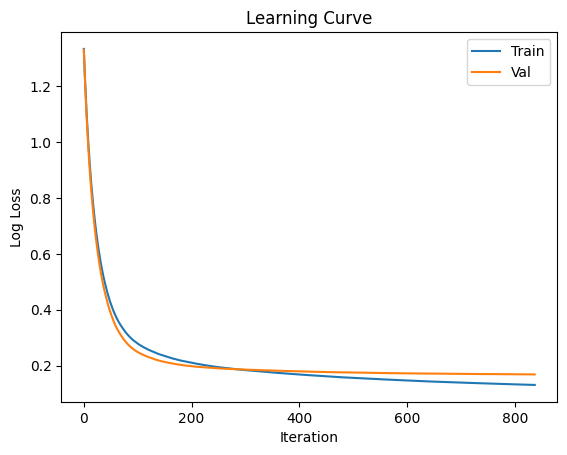

In [11]:
results = model_classification.evals_result_
plt.plot(results['train']['multi_logloss'], label='Train')
plt.plot(results['val']['multi_logloss'],   label='Val')
plt.xlabel('Iteration'); plt.ylabel('Log Loss')
plt.legend(); plt.title('Learning Curve'); plt.show()

#### RESULT OF THE MODEL

In [12]:
y_pred = model_classification.predict_proba(X_test_sgkf)
y_pred_classes = np.argmax(y_pred, axis = 1)


print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
accuracy = accuracy_score(y_test_sgkf, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}\n")


# In ra Classification Report chi tiết (Precision, Recall, F1-score)
# Sử dụng le.classes_ để map ngược lại tên chuỗi ban đầu (phishing, benign, malware, defacement)
print("Báo cáo phân loại chi tiết:")
print(classification_report(y_test_sgkf,y_pred_classes, target_names=le.classes_))

# metadata của model
metadata = {
    'accuracy': float(accuracy),
    'best_iteration': model_classification.best_iteration_,
    'params': params,
    'features': X.columns.tolist(),
    'classes': le.classes_.tolist(),
    'trained_at': datetime.now().isoformat(),
    'n_train': len(X_train_sgkf), 'n_val': len(X_val_sgkf), 'n_test': len(X_test_sgkf)
}

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
Accuracy: 0.9346

Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

      benign       0.97      0.96      0.96     42808
  defacement       0.92      0.97      0.94      9531
     malware       0.91      0.89      0.90      4234
    phishing       0.82      0.83      0.82      9625

    accuracy                           0.93     66198
   macro avg       0.90      0.91      0.91     66198
weighted avg       0.94      0.93      0.93     66198



### SAVED MODEL, LABEL ENCODER AND METADATA OF MODEL

In [13]:
# lưu metadata của model bằng file json và lưu model vào file .txt
#lưu model vào file txt
model_file = 'lgb_url_classifier.txt'
model_classification.booster_.save_model(model_file)
print(f"Đã lưu mô hình tại: {model_file}")
#lưu LabelEncoder để map ngược lại số --> nhãn
le_file = 'label_encoder.joblib'
joblib.dump(le.classes_, le_file)
print(f"Đã lưu label encoder tại: {le_file}")
#lưu metadata của model vào file json
model_filename = 'lgb_url_classifier_metadata.json'
with open(model_filename, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Đã lưu mô hình + metadata thành công tại: {model_filename}")

Đã lưu mô hình tại: lgb_url_classifier.txt
Đã lưu label encoder tại: label_encoder.joblib
Đã lưu mô hình + metadata thành công tại: lgb_url_classifier_metadata.json


### Step 6: Display the confusion matrix

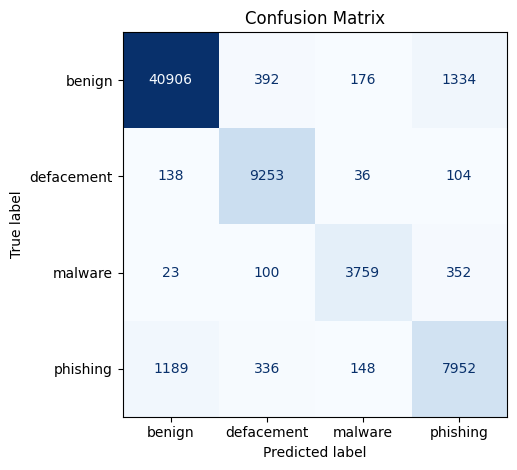

In [14]:
cm = confusion_matrix(y_test_sgkf, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Step 7: Check the importance of feature

['url', 'type', 'url length', 'scheme', 'netloc', 'path', 'query', 'fragment', 'subdomain', 'domain', 'number_of_part', 'has_scheme', 'has_netloc', 'has_path', 'has_params', 'has_query', 'has_fragment', 'has_username', 'has_password', 'has_port', 'has_subdomain', 'has_domain', 'has_suffix', 'netloc_length', 'path_length', 'query_length', 'fragment_length', 'subdomain_length', 'domain_length', 'url_entropy', 'netloc_entropy', 'path_entropy', 'query_entropy', 'subdomain_entropy', 'domain_entropy', 'hyphen_in_subdomain', 'hyphen_in_domain', 'unicode', 'punycode', 'at_sign_in_netloc', 'slash_in_path', 'dot_in_path', 'strange_in_query', 'equal_in_query', 'ampersand_in_query', 'number_subdomain', 'normalized_levenshtein_domain', 'normalized_levenshtein_subdomain', 'random_domain_check', 'random_subdomain_check', 'number_ratio_domain', 'number_ratio_subdomain', 'repeated_domain_check', 'repeated_path_check', 'repeated_url_check', 'longest_repeated_chain', 'ip_domain', 'suspicious_key_domain',

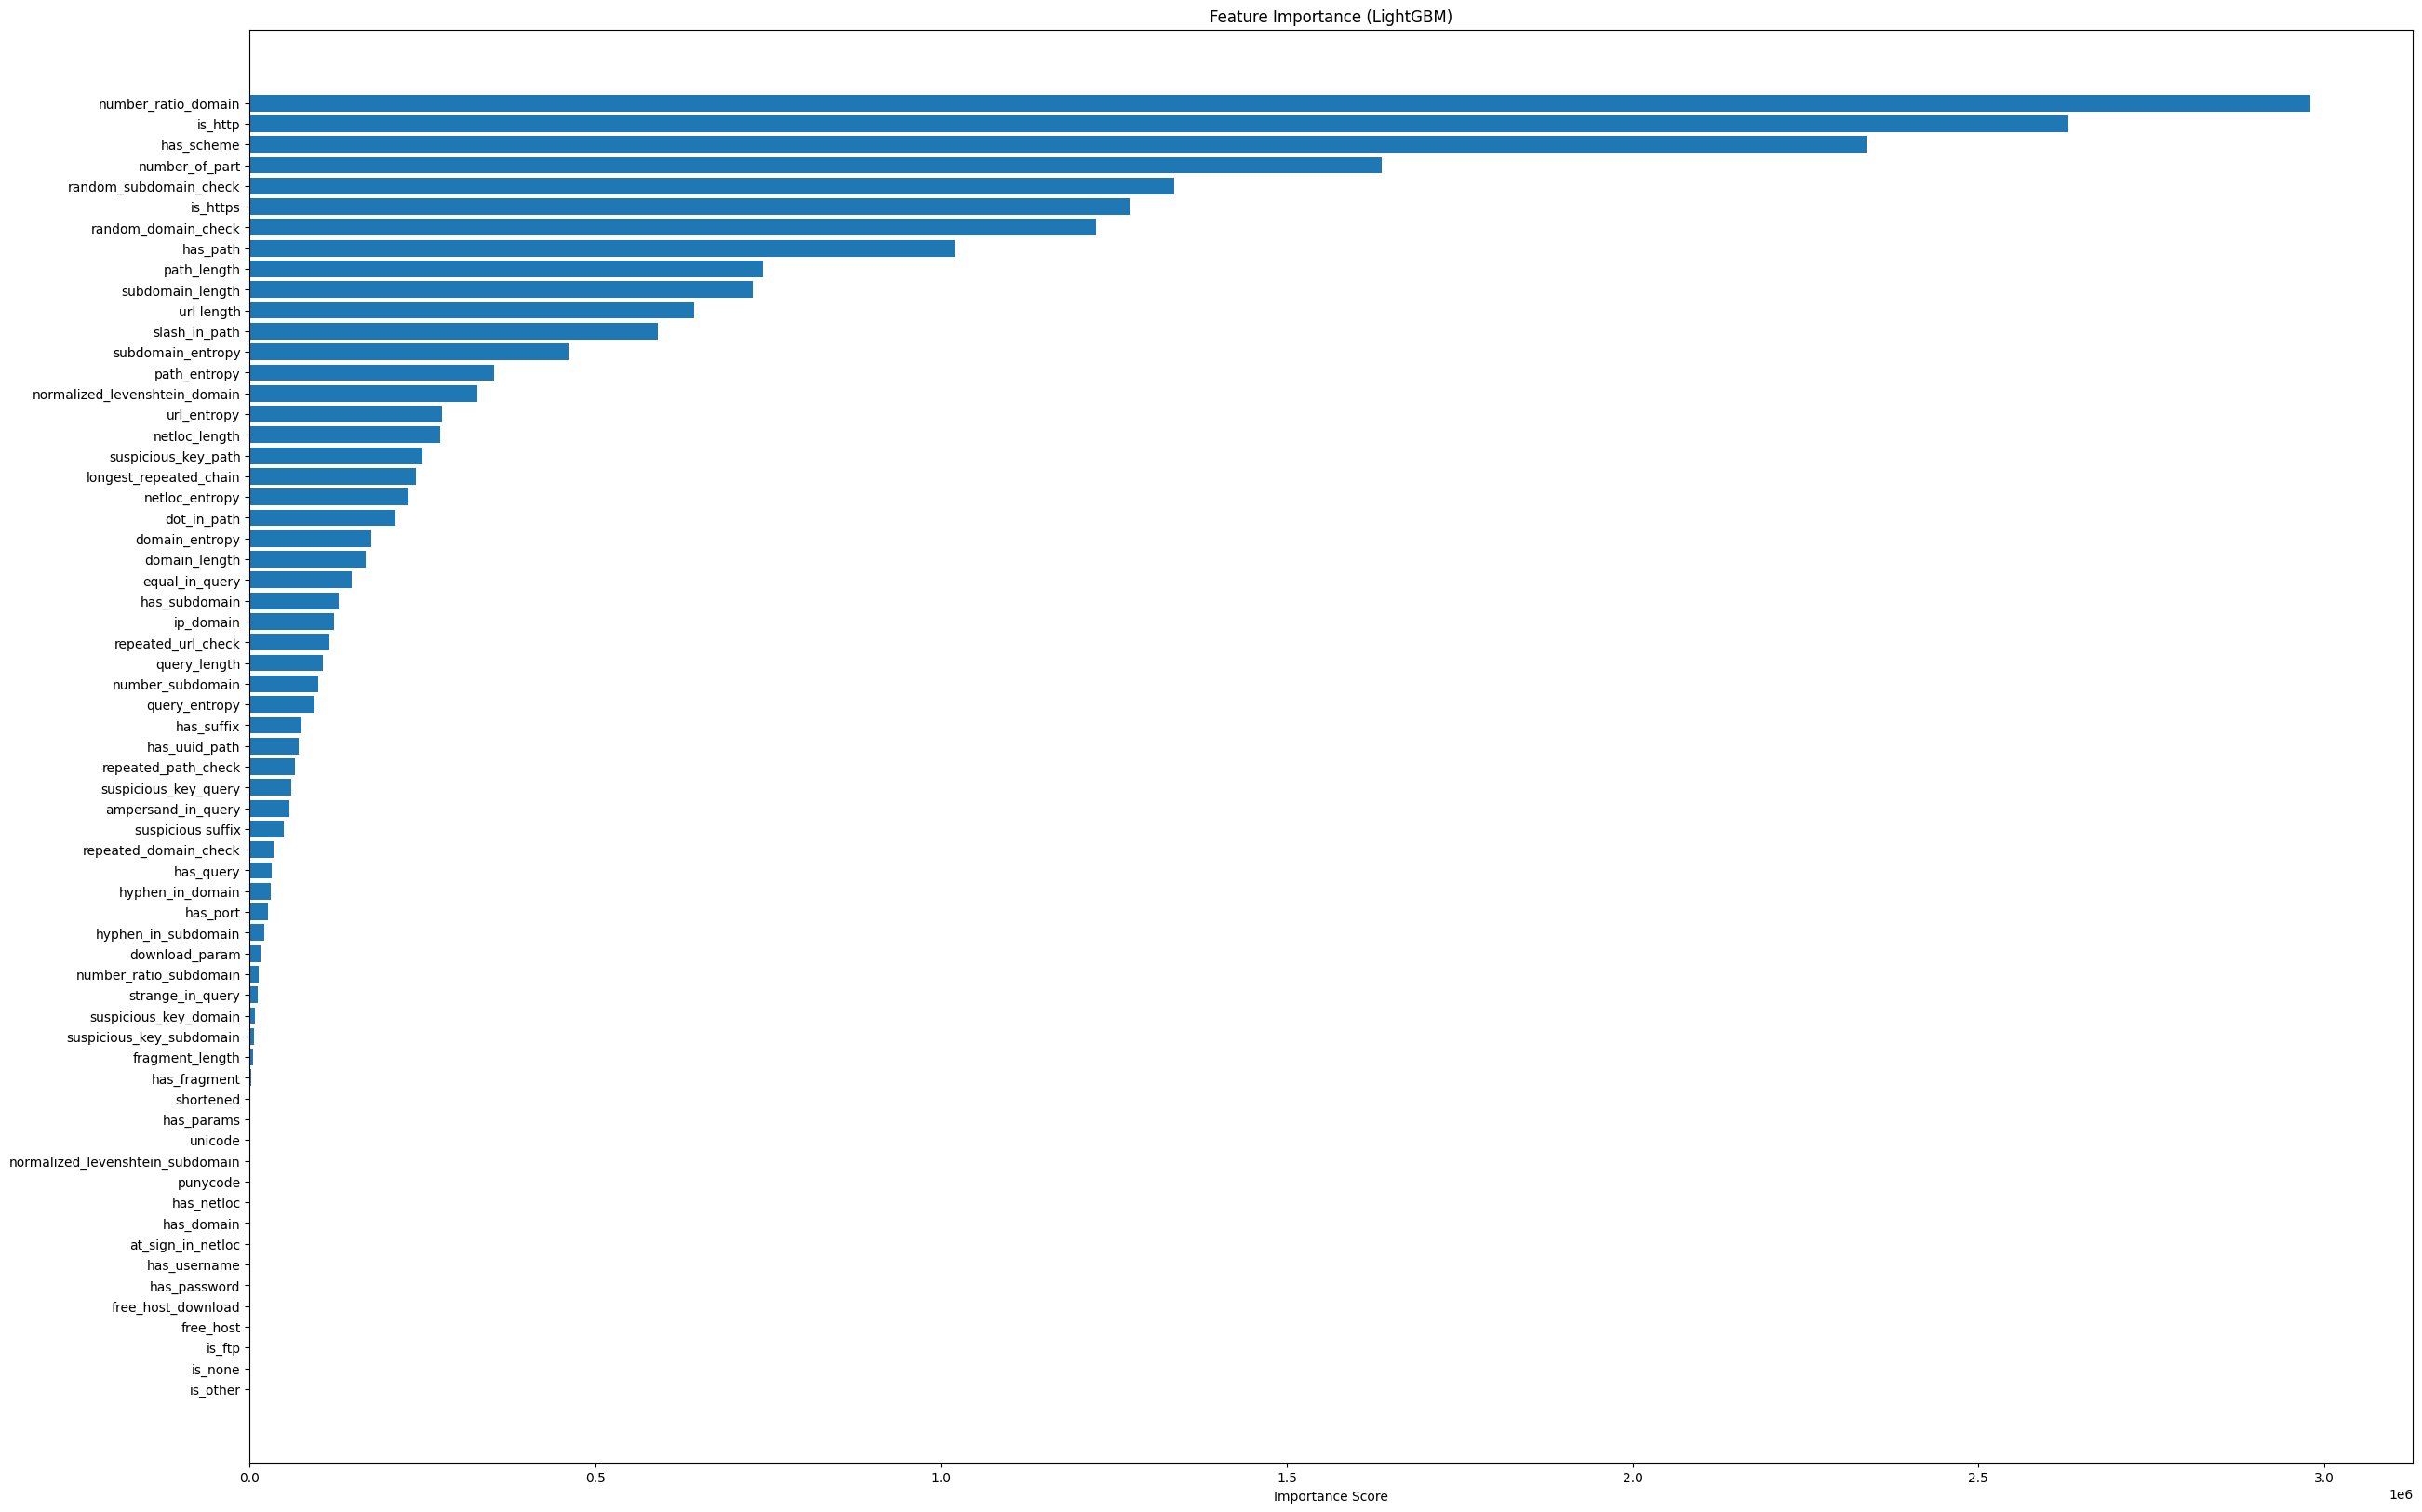

In [15]:
col_list = url_data.columns.tolist()
print(col_list)

importances = model_classification.booster_.feature_importance(importance_type = 'gain')
importance_df = pd.DataFrame(
    {
        "feature" : X.columns,
        "importance" : importances
    }
).sort_values(by="importance", ascending = False)
print(importance_df)

plt.figure(figsize=(30,20))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (LightGBM)")
plt.xlabel("Importance Score")
plt.show()

### Step 7: SHAP analysis


--- benign ---


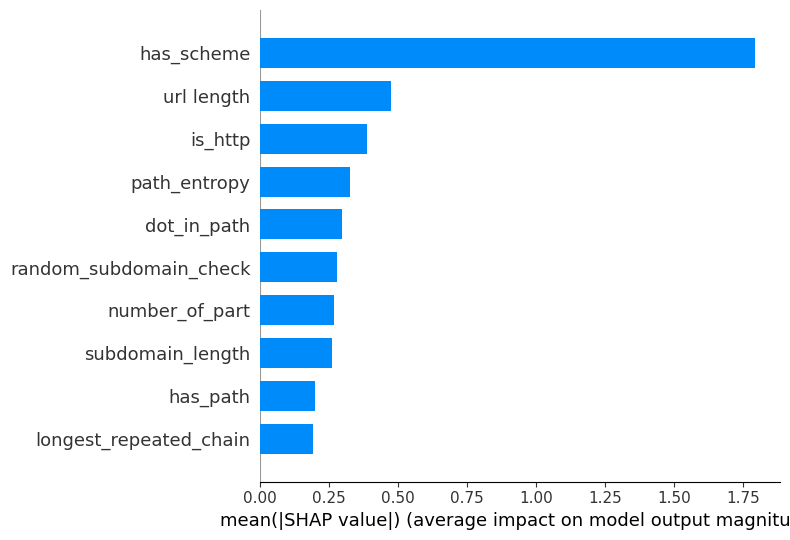


--- defacement ---


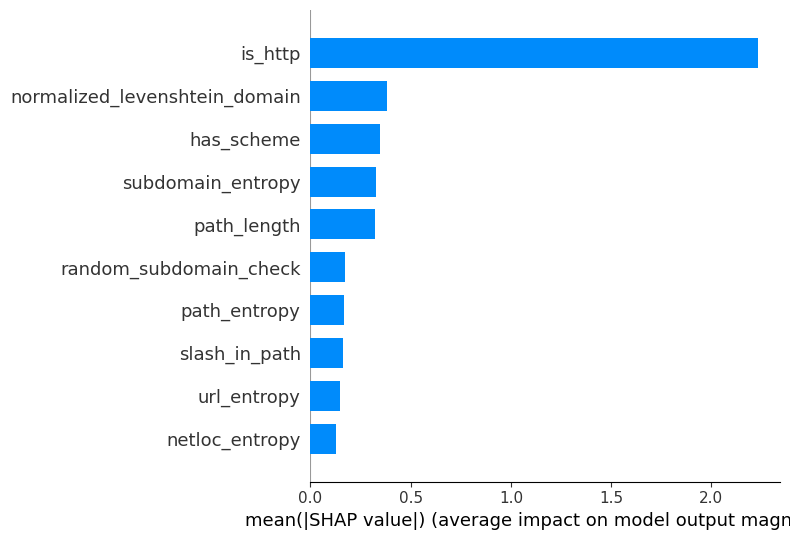


--- malware ---


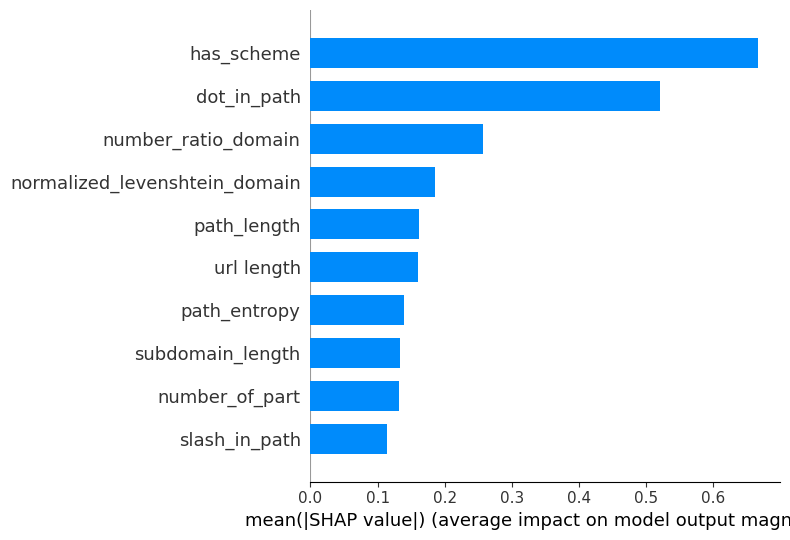


--- phishing ---


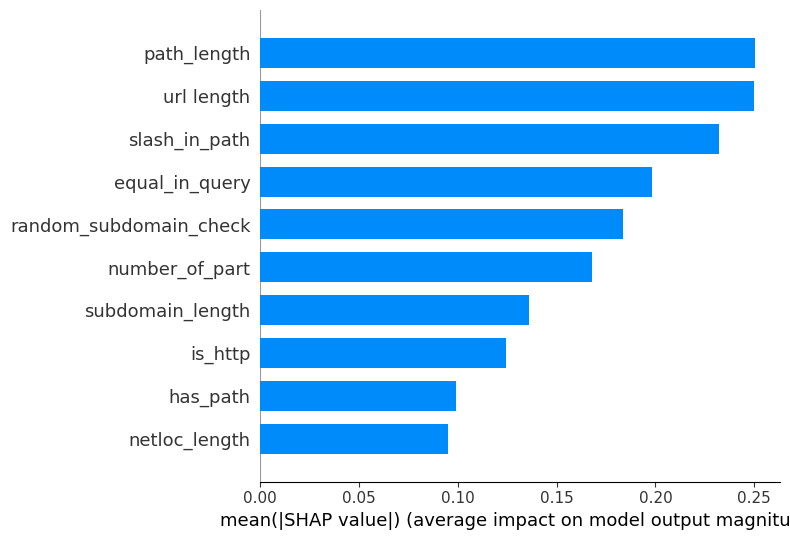

In [16]:
import shap

explainer = shap.TreeExplainer(model_classification)
shap_values = explainer.shap_values(X_test_sgkf)

# Top features ảnh hưởng nhất với từng lớp
for i, class_name in enumerate(le.classes_):
    print(f"\n--- {class_name} ---")
    shap.summary_plot(
        shap_values[:,:,i], X_test_sgkf,
        feature_names=X_test_sgkf.columns,
        plot_type='bar',
        show=True,
        max_display=10
    )